In [1]:
import torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import Optimizer
import torch.backends.cudnn as cudnn
import torchvision
from torch.utils.data import TensorDataset, DataLoader, Dataset
import os
import random
import matplotlib.pyplot as plt
import numpy as np
# import hypergrad as hg
import tqdm
import imageio
import torchvision.transforms as transforms
import copy
from new_poi_util import *
import time
import torchshow as ts
from torch.autograd import Variable
import h5py
from models import ResNet18, PreActResNet18

random_seed = 0

set_seed(random_seed)

torch.cuda.empty_cache()
torch.cuda.set_device(5)
device = 'cuda'

In [2]:
class Args:
    num_classes = 43
#     lr = 1e-2
    lr = 2e-1
    momentum = 0.9
    nesterov = True
    weight_decay = 5e-4
    dampening = 0
    meta_lr = 0.00005
    meta_weight_decay = 1e-4
    warmup_epochs = 1
    regularization = True
    
    #FaMUS Techniques
    top_k = 15
    go_lr = 1e-1
    num_act = 4
    mse_factor = 1e-1
    act_factor = 1e-1
    res_epochs = 1
    corruption_type = 'backdoor'
    corruption_ratio = 0.0268
    batch_size = 128
    num_workers = 16
    tar_lab = 12
    repeat_rounds = 5
args=Args()

In [3]:
test_transform = transforms.Compose([transforms.ToTensor(),])

train_path = '/home/data/GTSRB/gtsrb_dataset.h5'
trainset = h5_dataset(train_path, True, test_transform)

train_poi_set, o_poi_idx = poi_dataset(trainset, poi_methond=args.corruption_type, transform=test_transform, poi_rates=args.corruption_ratio,random_seed=random_seed, tar_lab=args.tar_lab)
train_dataloader = torch.utils.data.DataLoader(train_poi_set, batch_size=args.batch_size, num_workers=args.num_workers, pin_memory=True, shuffle=True)

## Data Resilient

In [4]:
B = int(len(train_poi_set) / args.batch_size)
criterion = nn.CrossEntropyLoss(reduction='none').cuda()
# from util import AverageMeter

In [5]:
import tqdm
mnet_list = []
vnet_list = []
for i in range(args.repeat_rounds):
    model, optimizer_a, vnet, optimizer_c = build_training(args)
    grad_models, grad_optimizers = build_grad_models(args, model)
    model, optimizer_a = warmup(model, optimizer_a, train_dataloader, args)
    cudnn.benchmark = True
    raw_meta_model = ResNet18(num_classes = 43).cuda()
    for i in range(args.res_epochs):
        train_loss = 0
        train_iter = tqdm.notebook.tqdm(enumerate(train_dataloader), total=int(len(train_poi_set)/args.batch_size)+1)
        for iteration, (input_train, target_train) in train_iter:
            input_var,target_var = input_train.cuda(), target_train.cuda()

            # virtual training
            meta_model = copy.deepcopy(raw_meta_model)
            meta_model.load_state_dict(model.state_dict())
            y_f_hat = meta_model(input_var)
            cost = criterion(y_f_hat, target_var)
            cost_v = torch.reshape(cost, (len(cost), 1))
            v_lambda = vnet(cost_v.data)
            batch_size = v_lambda.size()[0]
            v_lambda = v_lambda.view(-1)
            v_lambda = norm_weight(v_lambda)
            l_f_meta = torch.sum(v_lambda * cost)

            # virtual backward & update
            meta_model.zero_grad()
            grads = torch.autograd.grad(l_f_meta,(meta_model.parameters()),create_graph=True, allow_unused=True)

            # compute gradient gates and update the model
            new_grads,_ = compute_gated_grad(grads, grad_models, args.top_k, args.num_act)
            pseudo_optimizer = MetaSGD(meta_model, meta_model.parameters(), lr=args.lr)
            pseudo_optimizer.load_state_dict(optimizer_a.state_dict())
            pseudo_optimizer.meta_step(new_grads)

            res_y_f_hat = meta_model(input_var)
            res_cost = criterion(res_y_f_hat, target_var)
            res_cost_v = torch.reshape(res_cost, (len(res_cost), 1))
            res_v_bf_lambda = vnet(res_cost_v.data)
            res_v_bf_lambda = res_v_bf_lambda.view(-1)
            res_v_lambda = 1-res_v_bf_lambda
            res_v_lambda = norm_weight(res_v_lambda)

            valid_loss = -torch.sum((res_v_lambda) * res_cost)

            ## meta backward & update
            mse_loss = 0.
            valid_params = list(meta_model.parameters())[-2::]
            valid_grads = torch.autograd.grad(valid_loss, tuple(valid_params), create_graph=True)

            ## compute last gradient loss
            for train_grad, valid_grad in zip(grads[-2::], valid_grads):
                if len(train_grad.size()) >= 2:
                    dim0 = train_grad.size()[0]
                    grad_target = valid_grad.detach()
                    g_mean, g_std = torch.mean(grad_target.view(dim0, -1), dim=-1), torch.std(grad_target.view(dim0, -1), dim=-1)
                    pg_mean, pg_std = torch.mean(train_grad.view(dim0, -1), dim=-1), torch.std(train_grad.view(dim0, -1), dim=-1)
                    mse_loss += (args.mse_factor * torch.mean((pg_mean - g_mean)**2 + (pg_std - g_std)**2))
                else:
                    grad_target = valid_grad.detach()
                    g_mean, g_std = torch.mean(grad_target), torch.std(grad_target)
                    pg_mean, pg_std = torch.mean(train_grad), torch.std(train_grad)
                    mse_loss += (args.mse_factor * torch.mean((pg_mean - g_mean)**2 + (pg_std - g_std)**2))
            valid_loss -= mse_loss
            
            optimizer_c.zero_grad()
            for go in grad_optimizers:
                go.zero_grad()
            valid_loss.backward()
            optimizer_c.step()
            for go in grad_optimizers:
                go.step()
            del grads, new_grads

            #actuall update
            y_f = model(input_var)
            cost_w = criterion(y_f, target_var)
            cost_v = torch.reshape(cost_w, (len(cost_w), 1))

            with torch.no_grad():
                w_new = vnet(cost_v)

            w_new = w_new.view(-1)#
            batch_size = w_new.size()[0]
            w_new = norm_weight(w_new)
            l_f = torch.sum(w_new * cost_w)

            optimizer_a.zero_grad()
            l_f.backward()
            optimizer_a.step()
    vnet_list.append(copy.deepcopy(vnet))
    mnet_list.append(copy.deepcopy(model))

Warmup Epoch 0 


  0%|          | 0/307 [00:00<?, ?it/s]

Warmup Epoch 0 


  0%|          | 0/307 [00:00<?, ?it/s]

Warmup Epoch 0 


  0%|          | 0/307 [00:00<?, ?it/s]

Warmup Epoch 0 


  0%|          | 0/307 [00:00<?, ?it/s]

Warmup Epoch 0 


  0%|          | 0/307 [00:00<?, ?it/s]

## Eval step

In [6]:
test_trans = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(25),
    transforms.ToTensor(),
])

train_path = '/home/data/GTSRB/gtsrb_dataset.h5'
test_trainset = h5_dataset(train_path, True, test_transform)
# Dataloaders below are used for training only
test_poi_set, poi_idx = poi_dataset(test_trainset, poi_methond=args.corruption_type, transform=test_trans, poi_rates=args.corruption_ratio,random_seed=random_seed, tar_lab=args.tar_lab)
# test_poi_set = train_poi_set
test_dataloader = torch.utils.data.DataLoader(test_poi_set, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers, pin_memory=True)
clean_idx = list(set(np.arange(len(test_poi_set))) - set(poi_idx))
test_cross_entropy = nn.CrossEntropyLoss()

In [7]:
v_res = []
for i in range(args.repeat_rounds):
    v = np.zeros((len(train_poi_set)), dtype=np.float32)
    meta_model = mnet_list[i]
    meta_model.eval()
    vnet = vnet_list[i]
    # meta_model.train()
    for b, (images, labels) in tqdm.notebook.tqdm(enumerate(test_dataloader),total=B):
        input_var, target_var = images.cuda(), labels.cuda()
        y_f_hat = meta_model(input_var)
        cost = criterion(y_f_hat, target_var)
        cost_v = torch.reshape(cost, (len(cost), 1))
        
        v_lambda = vnet(cost_v.data)
        batch_size = v_lambda.size()[0]
        v_lambda = v_lambda.view(-1)
        
        zero_idx = b*batch_size
        v[zero_idx:zero_idx+batch_size] = v_lambda.detach().cpu().numpy()
    v_res.append(copy.deepcopy(v))

  0%|          | 0/306 [00:00<?, ?it/s]

  0%|          | 0/306 [00:00<?, ?it/s]

  0%|          | 0/306 [00:00<?, ?it/s]

  0%|          | 0/306 [00:00<?, ?it/s]

  0%|          | 0/306 [00:00<?, ?it/s]

In [8]:
pick_p = 100
new_mat = np.mean(v_res,axis=0)
new_idx = []
tar_idx = np.where(np.array(test_poi_set.targets) == args.tar_lab)[0]
p_tail = (len(tar_idx) - pick_p)/len(tar_idx)*100
p_tail2 = (len(tar_idx) - 2*pick_p)/len(tar_idx)*100
cutting = np.percentile(new_mat[tar_idx],p_tail)
cutting2 = np.percentile(new_mat[tar_idx],p_tail2)
tar_new_idx = np.where((new_mat[tar_idx]>=cutting2)&(new_mat[tar_idx]<=cutting))[0]
if tar_new_idx.shape[0] > pick_p:
    tar_new_idx = tar_new_idx[:pick_p]
new_idx.append(tar_idx[tar_new_idx])
new_idx = [i for item in new_idx for i in item]
new_idx = np.array(new_idx)
print('Size of v:',new_idx.shape)
gd_rt = len(list(set(clean_idx).intersection(set(new_idx))))/len(set(new_idx))
bd_detect_rt = len(list(set(poi_idx).intersection(set(new_idx))))/len(set(poi_idx))
print('Good rate of v',gd_rt)
print('Bad rate of v',1-gd_rt)
print('Backdoor selected rate',bd_detect_rt)

Size of v: (100,)
Good rate of v 1.0
Bad rate of v 0.0
Backdoor selected rate 0.0


In [16]:
from matplotlib.colors import LinearSegmentedColormap
colors = [(0, "#ff5858"), (1, "#b7d79e")]
cmap = LinearSegmentedColormap.from_list("bwwr", colors)

def bar_plot(v_res, test_set, tar_lab, poi_idx, datapoint):
    clean_idx = list(set(np.arange(len(test_set))) - set(poi_idx))
    x= [i for i in range(len(datapoint))]
    res = []
    for d in datapoint:
        pick_p = d
        new_mat = np.mean(v_res,axis=0)
        std = np.std(v_res,axis=0)
        new_idx = []
        tar_idx = np.where(np.array(test_set.targets) == tar_lab)[0]
        p_tail = (len(tar_idx) - pick_p)/len(tar_idx)*100
        cutting = np.percentile(new_mat[tar_idx],p_tail)
        tar_new_idx = np.where(new_mat[tar_idx]>=cutting)[0]
        if tar_new_idx.shape[0] > pick_p:
            tar_new_idx = tar_new_idx[:pick_p]
        new_idx.append(tar_idx[tar_new_idx])
        new_idx = np.array([i for item in new_idx for i in item])
        gd_rt = len(list(set(clean_idx).intersection(set(new_idx))))/len(set(new_idx))
        res.append(gd_rt)
    
    n = 1.0
    plt.figure(figsize=(9*n,7*n))
    plt.ylim(min(res)-0.05, 1.001)
    plt.xticks(x,datapoint)
    norm = plt.Normalize(np.array(res).min(), np.array(res).max())
    norm_y = norm(res)
    color = cmap(norm_y)
    plt.bar(x,res, color = color)

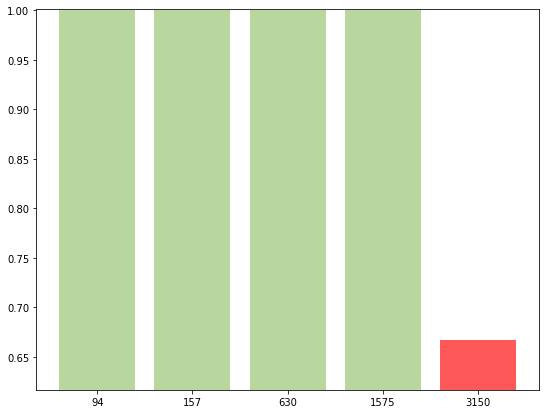

In [17]:
percent = [3/100,5/100,20/100,50/100,100/100]
datapoint = [int(i*len(np.where(np.array(test_poi_set.targets)==12)[0])) for i in percent]
bar_plot(v_res, test_poi_set, args.tar_lab, poi_idx, datapoint)

In [13]:
total_pick = 1000

import math
class_per = []
for i in np.unique(test_poi_set.targets):
    percent = len(np.where(np.array(test_poi_set.targets) == i)[0])/len(test_poi_set)
    class_per.append(math.ceil(total_pick*percent))

new_mat = np.mean(v_res,axis=0)
new_idx = []
for i in range(42):
    pick_p = class_per[i]
    tar_idx = np.where(np.array(test_poi_set.targets) == i)[0]
    p_tail = (len(tar_idx) - pick_p)/len(tar_idx)*100
    cutting = np.percentile(new_mat[tar_idx],p_tail)
    tar_new_idx = np.where(new_mat[tar_idx]>=cutting)[0]
    if tar_new_idx.shape[0] > pick_p:
        tar_new_idx = tar_new_idx[:pick_p]
    new_idx.append(tar_idx[tar_new_idx])
new_idx = [i for item in new_idx for i in item]
new_idx = np.array(new_idx)
print('Size of v:',new_idx.shape)
gd_rt = len(list(set(clean_idx).intersection(set(new_idx))))/len(set(new_idx))
bd_detect_rt = len(list(set(poi_idx).intersection(set(new_idx))))/len(set(poi_idx))
print('Clean rate of v',gd_rt)
print('Poison rate of v',1-gd_rt)
print('Bad samples selected rate',bd_detect_rt)

Size of v: (1015,)
Clean rate of v 1.0
Poison rate of v 0.0
Bad samples selected rate 0.0
